# 3.1 Recover two known transforms

3.1 Recover two known transforms: A (levels operation, monotonic) and
B (grey-level slicing, non-monotonic). Fits, scatter+curve overlay,
breakpoint/slope table, and re-application error, saved for the report.

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
sys.path.insert(0, str(Path.cwd()))
from starter import transfer_curve, fit_piecewise, apply_recovered

ROOT = Path.cwd().parents[1]

In [4]:
field_in = np.asarray(Image.open(ROOT / "Images/input/P3/field_in.png"))
out_A = np.asarray(Image.open(ROOT / "Images/input/P3/field_out_A.png"))
out_B = np.asarray(Image.open(ROOT / "Images/input/P3/field_out_B.png"))

In [5]:
results = {}
for name, img_out in (("A", out_A), ("B", out_B)):
    T, cnt = transfer_curve(field_in, img_out)
    bps, slopes, inter, k = fit_piecewise(T, cnt, max_seg=6)
    recon = apply_recovered(field_in, bps, slopes, inter)
    err = np.abs(recon.astype(np.float64) - img_out.astype(np.float64))
    results[name] = dict(T=T, cnt=cnt, bps=bps, slopes=slopes, inter=inter,
                          k=k, max_err=err.max(), mean_err=err.mean())
    print(f"{name}: k={k}  breakpoints={bps}  slopes={np.round(slopes, 4)}  "
          f"max_err={err.max():.4f}  mean_err={err.mean():.6f}")

A: k=3  breakpoints=[  0  13  61 255]  slopes=[0.     3.9687 0.3334]  max_err=0.0000  mean_err=0.000000


B: k=4  breakpoints=[  0  70 111 151 255]  slopes=[ 0.285   5.3746 -5.3729 -0.1901]  max_err=0.0000  mean_err=0.000000


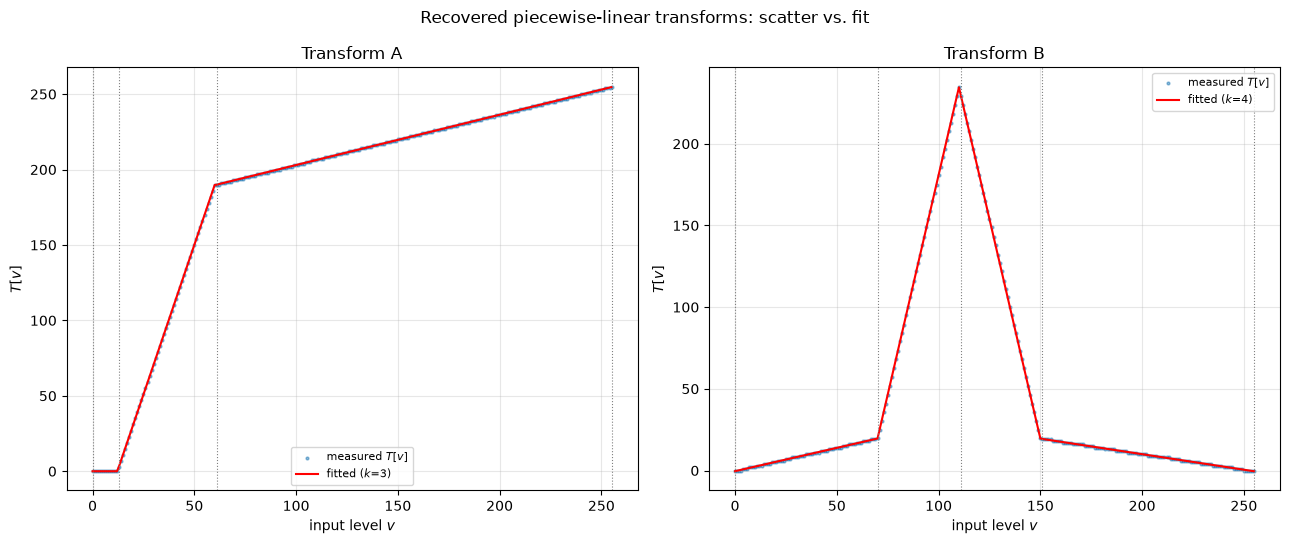

In [6]:
# --- scatter + fitted overlay -----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, name in zip(axes, ("A", "B")):
    r = results[name]
    supported = r["cnt"] > 0
    vs = np.where(supported)[0]
    ax.scatter(vs, r["T"][supported], s=4, alpha=0.5, label="measured $T[v]$")
    lut_v = np.arange(256)
    bps, slopes, inter = r["bps"], r["slopes"], r["inter"]
    lut = np.zeros(256)
    for v in lut_v:
        seg = min(max(np.searchsorted(bps, v, side="right") - 1, 0), len(slopes) - 1)
        lut[v] = slopes[seg] * v + inter[seg]
    ax.plot(lut_v, lut, color="red", linewidth=1.5, label=f"fitted ($k$={r['k']})")
    for bp in bps:
        ax.axvline(bp, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xlabel("input level $v$")
    ax.set_ylabel("$T[v]$")
    ax.set_title(f"Transform {name}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Recovered piecewise-linear transforms: scatter vs. fit")
fig.tight_layout()
plt.show()

In [7]:
# --- breakpoint/slope table --------------------------------------------
print(f"{'Pair':4s} {'Seg':4s} {'Range':>12s} {'Slope':>9s} {'Intercept':>10s} "
      f"{'Max err':>8s} {'Mean err':>9s}")
for name in ("A", "B"):
    r = results[name]
    for i in range(r["k"]):
        lo, hi = r["bps"][i], r["bps"][i + 1]
        err_cols = f"{r['max_err']:8.3f} {r['mean_err']:9.5f}" if i == 0 else f"{'--':>8s} {'--':>9s}"
        print(f"{name:4s} {i+1:4d} [{lo:3d},{hi:3d}] {r['slopes'][i]:9.4f} "
              f"{r['inter'][i]:10.2f} {err_cols}")

Pair Seg         Range     Slope  Intercept  Max err  Mean err
A       1 [  0, 13]    0.0000       0.00    0.000   0.00000
A       2 [ 13, 61]    3.9687     -48.36       --        --
A       3 [ 61,255]    0.3334     169.66       --        --
B       1 [  0, 70]    0.2850      -0.40    0.000   0.00000
B       2 [ 70,111]    5.3746    -356.64       --        --
B       3 [111,151]   -5.3729     825.54       --        --
B       4 [151,255]   -0.1901      48.03       --        --
